In [17]:
import cv2
import numpy as np
import glob
import math
import matplotlib.pyplot as plt
import os

In [18]:
# --- 1. Configuration ---
# IMPORTANT: This is the number of INNER corners, not the number of squares!
# A standard 10x7 square board has 9x6 inner corners.
CHESSBOARD_SIZE = (9, 6) 

# Measure a single square on your physical printed board in METERS
SQUARE_SIZE_M = 0.1 

# Sub-pixel optimization criteria for maximum precision
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)

In [19]:

def visualize_checkerboard(image_path, grid_size=(9, 6)):
    """
    Loads an image, detects the checkerboard grid, and visually displays the result using matplotlib.
    Returns True if successful, False otherwise.
    """
    img = cv2.imread(image_path)
    if img is None:
        return False

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print(f"Testing {os.path.basename(image_path)}...")

    # Standard attempt
    flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK
    ret, corners = cv2.findChessboardCorners(gray, grid_size, flags)

    # Fallback: Underwater images often need contrast enhancement to find the grid
    if not ret:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_clahe = clahe.apply(gray)
        ret, corners = cv2.findChessboardCorners(gray_clahe, grid_size, flags)

    if ret:
        print(f"\nSuccess! Grid found in {os.path.basename(image_path)}.")
        
        # Refine the corner coordinates to sub-pixel accuracy
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

        # Draw the corners onto the original color image
        cv2.drawChessboardCorners(img, grid_size, corners_refined, ret)

        # Convert from BGR (OpenCV default) to RGB (Matplotlib default)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print("Close the matplotlib window to continue.")
        
        # Display using matplotlib
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.title(f'Checkerboard Visual Check: {os.path.basename(image_path)}')
        plt.axis('off') # Hide axes for a cleaner look
        plt.show()
        
        return True
    
    return False



In [20]:

# --- CONFIGURATION ---
# Provide the FOLDER path. The script will scan it to find the first working image.
FOLDER_PATH = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\processed\calibration-v2\selection_for_calibration\Left"


if not os.path.exists(FOLDER_PATH):
    print(f"Error: The folder '{FOLDER_PATH}' does not exist.")
else:
    # Grab all standard image formats in the folder
    image_files = glob.glob(os.path.join(FOLDER_PATH, "*.jpg")) + \
                    glob.glob(os.path.join(FOLDER_PATH, "*.jpeg")) + \
                    glob.glob(os.path.join(FOLDER_PATH, "*.png"))
    
    if not image_files:
        print(f"No images found in {FOLDER_PATH}.")
    else:
        print(f"Found {len(image_files)} images. Searching for the first valid calibration grid...\n")
        
        success = False
        for img_path in image_files:
            if visualize_checkerboard(img_path, CHESSBOARD_SIZE):
                success = True
                break  # Stop as soon as we find and plot one working image
        
        if not success:
            print("\nFailed to find the grid in ANY image in the folder. Troubleshooting tips:")
            print("1. Check CHESSBOARD_SIZE. It MUST be the exact number of internal intersections.")
            print("2. Ensure your images aren't too blurry and the whole board is fully in the frame.")

Error: The folder 'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\processed\calibration-v2\selection_for_calibration\Left' does not exist.


In [21]:
# --- 2. Prepare 3D World Points ---
# This creates a mathematical grid of where the corners SHOULD be in real space
objp = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD_SIZE[0], 0:CHESSBOARD_SIZE[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE_M

objpoints = []       # 3D points in real world space
imgpoints_left = []  # 2D points in left image plane
imgpoints_right = [] # 2D points in right image plane

In [22]:
import os
import re

# --- 3. Load and Sort Images ---
# We must use "natural sorting" so frame 2 comes before frame 10.
# This ensures the Left and Right arrays align perfectly despite missing culled frames.
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

LEFT_IMG_DIR = os.path.join(r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_calibration", "Left")
RIGHT_IMG_DIR = os.path.join(r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_calibration", "Right")

left_images = sorted(glob.glob(os.path.join(LEFT_IMG_DIR, '*.jpg')), key=natural_sort_key)
right_images = sorted(glob.glob(os.path.join(RIGHT_IMG_DIR, '*.jpg')), key=natural_sort_key)

# Safety check: Prevent OpenCV from crashing later if a file is missing
if len(left_images) != len(right_images):
    raise ValueError(f"Mismatch! Found {len(left_images)} left images and {len(right_images)} right images.")

if not left_images or not right_images:
    raise ValueError("No images found! Check your SELECTED-FRAMES folder paths.")

print(f"Found {len(left_images)} matched image pairs. Detecting sub-pixel corners...")

Found 53 matched image pairs. Detecting sub-pixel corners...


In [23]:
# --- 4. Feature Extraction Loop ---
valid_pairs = 0
for img_left_path, img_right_path in zip(left_images, right_images):
    img_left = cv2.imread(img_left_path)
    img_right = cv2.imread(img_right_path)
    
    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)
    
    # Find the rough corners
    ret_left, corners_left = cv2.findChessboardCorners(gray_left, CHESSBOARD_SIZE, None)
    ret_right, corners_right = cv2.findChessboardCorners(gray_right, CHESSBOARD_SIZE, None)
    
    # Only use pairs where the board was successfully found in BOTH images
    if ret_left and ret_right:
        objpoints.append(objp)
        
        # Sub-pixel refinement (This is where the real precision comes from)
        corners_left = cv2.cornerSubPix(gray_left, corners_left, (11, 11), (-1, -1), criteria)
        imgpoints_left.append(corners_left)
        
        corners_right = cv2.cornerSubPix(gray_right, corners_right, (11, 11), (-1, -1), criteria)
        imgpoints_right.append(corners_right)
        
        valid_pairs += 1

print(f"Successfully extracted corners from {valid_pairs} pairs.")

Successfully extracted corners from 12 pairs.


In [24]:
# --- 5. Individual Camera Calibration ---
print("Calibrating individual cameras...")
ret_L, mtx_L, dist_L, rvecs_L, tvecs_L = cv2.calibrateCamera(
    objpoints, imgpoints_left, gray_left.shape[::-1], None, None)

ret_R, mtx_R, dist_R, rvecs_R, tvecs_R = cv2.calibrateCamera(
    objpoints, imgpoints_right, gray_right.shape[::-1], None, None)

print(f"Left Camera RMS Error: {ret_L:.4f}")
print(f"Right Camera RMS Error: {ret_R:.4f}")

Calibrating individual cameras...
Left Camera RMS Error: 1.0412
Right Camera RMS Error: 0.7675


In [25]:
# --- 6. Stereo Calibration ---
print("Performing stereo calibration...")

# We lock the intrinsic matrices we just found. This forces the algorithm to 
# only calculate the physical translation and rotation between the two lenses.
flags = cv2.CALIB_FIX_INTRINSIC

ret_S, K1, D1, K2, D2, R, T, E, F = cv2.stereoCalibrate(
    objpoints, imgpoints_left, imgpoints_right, 
    mtx_L, dist_L, mtx_R, dist_R, 
    gray_left.shape[::-1], criteria=criteria, flags=flags)

print(f"Stereo Calibration RMS Error: {ret_S:.4f}")
print("--- Stereo Matrices ---")
print(f"Translation Vector (T):\n{T}")

Performing stereo calibration...
Stereo Calibration RMS Error: 2.0732
--- Stereo Matrices ---
Translation Vector (T):
[[-1.36225444]
 [ 0.0052207 ]
 [ 0.34100191]]


In [26]:
np.savez('stereo_matrices.npz', K1=K1, D1=D1, K2=K2, D2=D2, R=R, T=T)
print("Stereo matrices saved to 'stereo_matrices.npz'")

Stereo matrices saved to 'stereo_matrices.npz'


## Stereo Length Interactive Check On Image

In [27]:
def load_calibration(npz_file):
    """Loads stereo calibration parameters from an .npz file."""
    with np.load(npz_file) as data:
        K1 = data['K1'] 
        D1 = data['D1'] 
        K2 = data['K2'] 
        D2 = data['D2'] 
        R = data['R']   
        T = data['T']   
    return K1, D1, K2, D2, R, T

def get_clicked_points(image, window_name, num_points=2):
    """Displays an image and records mouse clicks."""
    points = []
    
    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append([x, y])
            # Draw a small red circle where the user clicks
            cv2.circle(image, (x, y), 5, (0, 0, 255), -1)
            cv2.imshow(window_name, image)
            
    cv2.namedWindow(window_name)
    cv2.setMouseCallback(window_name, mouse_callback)
    
    print(f"[{window_name}] Please click {num_points} points, then press any key.")
    cv2.imshow(window_name, image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    return np.array(points, dtype=np.float32)

# Helper function to draw on a single image
def draw_measurement(image, points, measurement_text):
    # Convert floats to ints for pixel coordinates
    p1 = (int(points[0][0]), int(points[0][1]))
    p2 = (int(points[1][0]), int(points[1][1]))
    
    # Draw a yellow line between the points
    cv2.line(image, p1, p2, (0, 255, 255), 2)
    
    # Calculate the midpoint to place the text
    midpoint = ((p1[0] + p2[0]) // 2, (p1[1] + p2[1]) // 2)
    
    # Offset the text slightly so it doesn't cover the line
    text_pos = (midpoint[0], midpoint[1] - 10)
    
    # Draw the text in bright green
    cv2.putText(image, measurement_text, text_pos, 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)

Click on two ends of an object you want to measure.
[Left Image] Please click 2 points, then press any key.
[Right Image] Please click 2 points, then press any key.


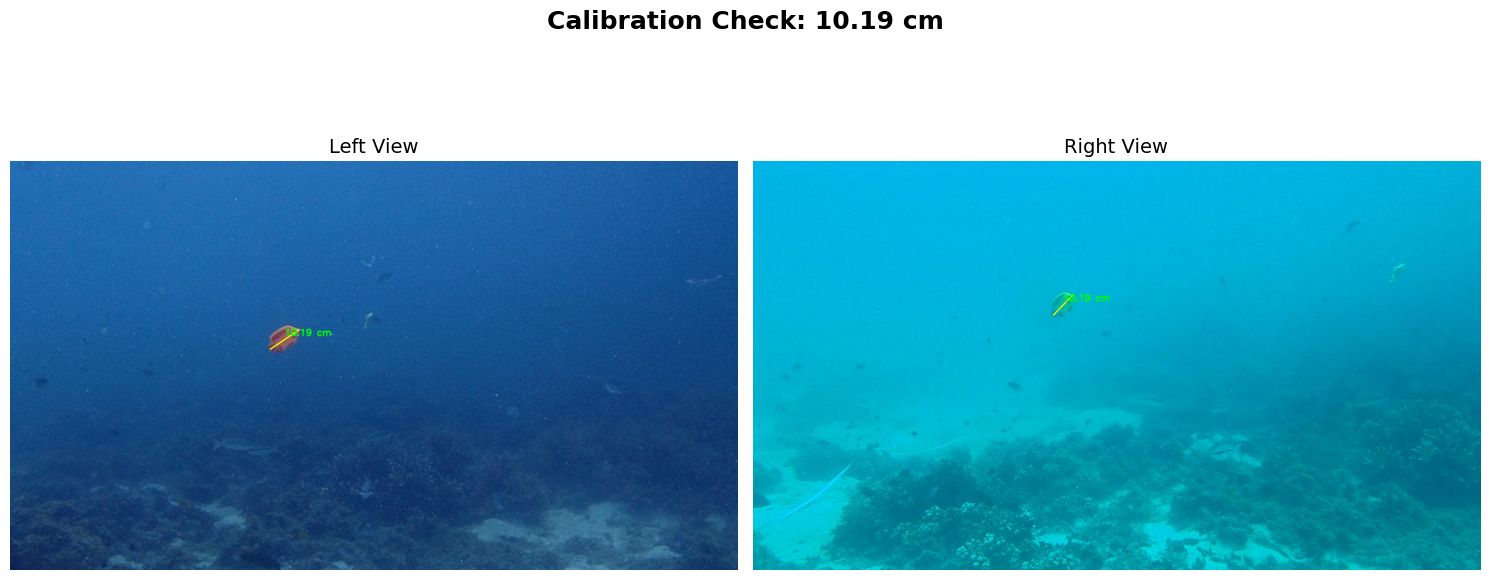

In [34]:


def main():
    # 1. File Paths 
    calib_file = 'stereo_matrices.npz'
    
    # UMT Dataset (Real-world underwater images with known scale)
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\raw\UMT\Images 4-190717\St9-Geluk West\TG4 Black(L) images s9 (P.G)\St9_0-25m(L).MOV-20.jpg'
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\raw\UMT\Images 4-190717\St9-Geluk West\TG4 Red(R) images st9 (P.G)\St9_0-25m(R).MOV-20.jpg'
    
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASETS FOR POSE ESTIMATION\UMT_dataset\BACKUP\Original Dataset\Images 1-190714\St3-Pantai Vietnam\TG4-Black(L) Images st3 (P.V)\St3_0-25m(L).MOV-1.jpg'
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASETS FOR POSE ESTIMATION\UMT_dataset\BACKUP\Original Dataset\Images 1-190714\St3-Pantai Vietnam\TG4-Red(R) Images st3 (P.V)\St3_0-25m(R).MOV-1.jpg'
    
    # Calibration Objects
    
    # Ground Truth No.1 
    LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_ground_truth\LEFT\ground_truth_1-Left-Frame-134.jpg'   # Replace with a real image path
    RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_ground_truth\RIGHT\ground_truth_1-Right-Frame-134.jpg'
    
    # Ground Truth No.2    
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\LEFT\GT-Meters-Left-Frame-297.jpg'   # Replace with a real image path
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\RIGHT\GT-Meters-Right-Frame-297.jpg'
    
    # Ground Truth No.3
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\LEFT\GT-Meters-Left-Frame-298.jpg'   # Replace with a real image path
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\RIGHT\GT-Meters-Right-Frame-298.jpg'
    
    # Ground Truth No.4
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\LEFT\GT-Meters-Left-Frame-299.jpg'   # Replace with a real image path
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\RIGHT\GT-Meters-Right-Frame-299.jpg'
    
    # Ground Truth No.5
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\LEFT\GT-Meters-Left-Frame-307.jpg'   # Replace with a real image path
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-GT\RIGHT\GT-Meters-Right-Frame-307.jpg'
    
    
    # Calibration Grid
    
    # LEFT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-FRAMES\Left\2-Meters-Left-Frame-98.jpg'
    # RIGHT_TEST_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\SELECTED-FRAMES\Right\2-Meters-Right-Frame-98.jpg'
    
    # 2. Load Parameters and Images
    K1, D1, K2, D2, R, T = load_calibration(calib_file)
    img_left = cv2.imread(LEFT_TEST_IMAGE)
    img_right = cv2.imread(RIGHT_TEST_IMAGE)

    if img_left is None or img_right is None:
        print("Error: Could not load images.")
        return

    # Keep a clean copy for the final drawing
    final_left = img_left.copy()
    final_right = img_right.copy()

    # 3. Get 2D Point Correspondences
    print("Click on two ends of an object you want to measure.")
    pts_left = get_clicked_points(img_left, "Left Image")
    pts_right = get_clicked_points(img_right, "Right Image")

    if len(pts_left) != 2 or len(pts_right) != 2:
        print("Error: You must click exactly 2 points in each image.")
        return

    # 4. Undistort the clicked points
    pts_left_undist = cv2.undistortPoints(pts_left.reshape(-1, 1, 2), K1, D1, P=K1)
    pts_right_undist = cv2.undistortPoints(pts_right.reshape(-1, 1, 2), K2, D2, P=K2)

    # 5. Build Projection Matrices
    P1 = K1 @ np.hstack((np.eye(3), np.zeros((3, 1))))
    P2 = K2 @ np.hstack((R, T))

    # 6. Triangulate Points
    pts4D = cv2.triangulatePoints(P1, P2, pts_left_undist.reshape(2, 2).T, pts_right_undist.reshape(2, 2).T)

    # 7. Convert to 3D (Raw unit: Meters based on previous troubleshooting)
    pts3D = pts4D[:3, :] / pts4D[3, :]

    # 8. Calculate Distance
    ptA = pts3D[:, 0]
    ptB = pts3D[:, 1]
    distance_raw_m = np.linalg.norm(ptA - ptB)
    distance_cm = distance_raw_m * 100.0  # Convert to cm

    # --- 9. Plotting on Images ---

    # Prepare the text string
    text_overlay = f"{distance_cm:.2f} cm"

    # Draw on both images using the OpenCV helper function
    draw_measurement(final_left, pts_left, text_overlay)
    draw_measurement(final_right, pts_right, text_overlay)

    # --- 10. Matplotlib Inline Plotting ---
    
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    final_left_rgb = cv2.cvtColor(final_left, cv2.COLOR_BGR2RGB)
    final_right_rgb = cv2.cvtColor(final_right, cv2.COLOR_BGR2RGB)

    # Create a side-by-side plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

    # Plot Left
    ax1.imshow(final_left_rgb)
    ax1.set_title("Left View", fontsize=14)
    ax1.axis('off') # Hides the pixel axes

    # Plot Right
    ax2.imshow(final_right_rgb)
    ax2.set_title("Right View", fontsize=14)
    ax2.axis('off')

    # Add a main title with the measurement
    plt.suptitle(f"Calibration Check: {distance_cm:.2f} cm", fontsize=18, fontweight='bold')
    
    # Render inline
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
